
ОБУЧЕНИЕ МОДЕЛИ IMAGE CAPTIONING В CLEARML (STAGE 2)
Получение датасетов из ClearML...
Датасет изображений найден: 3922646db1fa426396fef0bdbf67c237
Датасет аннотаций найден: 129ba1d727f94342bf483b35cf598d2b
Изображения: C:/Users/Ramil/.clearml/cache/storage_manager/datasets/ds_3922646db1fa426396fef0bdbf67c237
Аннотации: C:\Users\Ramil\.clearml\cache\storage_manager\datasets\ds_129ba1d727f94342bf483b35cf598d2b\captions_val2014.json
Аннотации загружены: 40504 изображений
Всего изображений: 40000
Train: 36000
Validation: 4000
ClearML Task: created new task id=2cc7ff9ee09449cdb432cbead3b9f5e4
ClearML results page: https://app.clear.ml/projects/ae84c10aebb648bab249558edd7a8a48/experiments/2cc7ff9ee09449cdb432cbead3b9f5e4/output/log
ClearML Task создана: 2cc7ff9ee09449cdb432cbead3b9f5e4
Словарь создан: 6507 слов

Обучение будет выполняться на: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Начинаем обучение...
Epoch 1/50, Train Loss: 4.5839, Val Loss: 4.0288
Epoch 2/50, Train Loss: 3.7949, Va

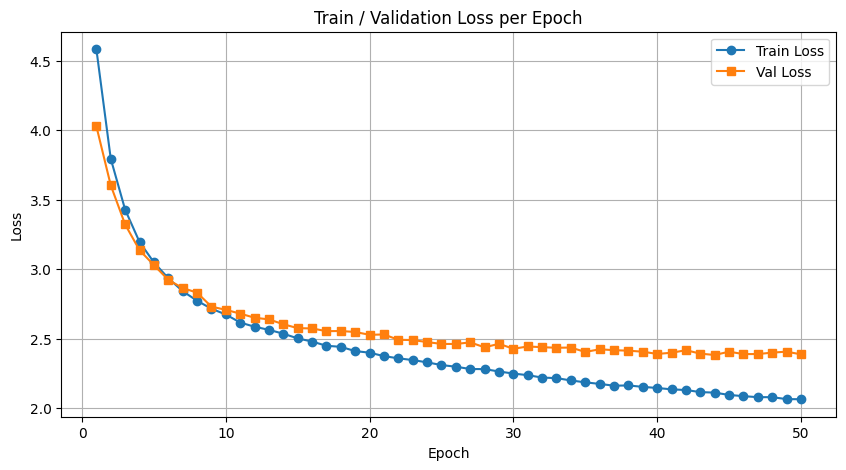

Обучение завершено! Модель и графики сохранены и залогированы в ClearML.

Промежуточные примеры:


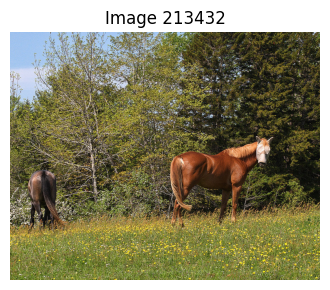

Image 213432:
  Actual:    Two horses grazing on green grass next to a forest.
  Predicted: a brown horse standing on a lush green field .



                                          0% | 0.00/119.22 MB [00:00<?, ?MB/s]: 

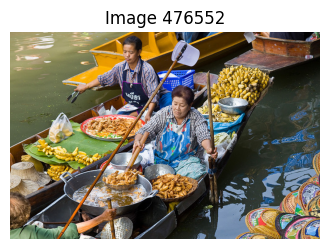

███▊                            13% | 15.00/119.22 MB [00:00<00:04, 25.13MB/s]: 

Image 476552:
  Actual:    four boats with people  carrying lots of bananas and other foods
  Predicted: a man is holding a bunch of bananas on a



███████▌                        25% | 30.00/119.22 MB [00:00<00:02, 34.07MB/s]: 

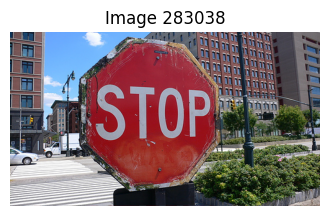

████████████▌                   42% | 50.00/119.22 MB [00:01<00:01, 35.56MB/s]: 

Image 283038:
  Actual:    a old rusty stop sign out sign some buildings.
  Predicted: a stop sign in a foreign language in the snow



████████████████▎               55% | 65.00/119.22 MB [00:01<00:01, 35.46MB/s]: 

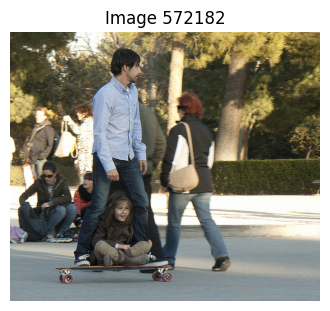

██████████████████████▋         75% | 90.00/119.22 MB [00:02<00:00, 34.63MB/s]: 

Image 572182:
  Actual:    A man riding a skateboard has a child between his legs. 
  Predicted: a group of people riding skateboards on a sidewalk .



███████████████████████▉        80% | 95.00/119.22 MB [00:02<00:00, 29.76MB/s]: 

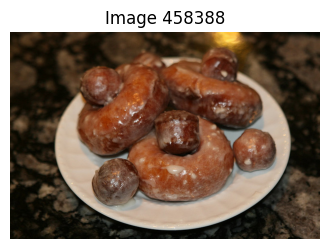

█████████████████████████████ 100% | 119.22/119.22 MB [00:03<00:00, 36.04MB/s]: 

Image 458388:
  Actual:    A plate with glazed donuts and donuts holes on it.
  Predicted: a bunch of doughnuts that are on a plate .



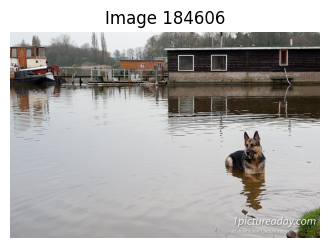

█████████████████████████████ 100% | 119.22/119.22 MB [00:04<00:00, 28.46MB/s]: 


Image 184606:
  Actual:    A dog is standing in floodwater beside a house.
  Predicted: a dog is standing in the water near a boat



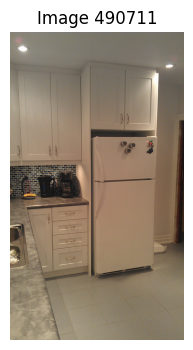

Image 490711:
  Actual:    A white refrigerator freezer sitting inside of a kitchen.
  Predicted: a kitchen with a stove , microwave , and refrigerator



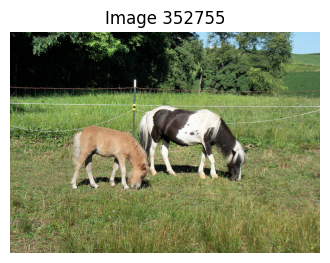

Image 352755:
  Actual:    Two ponies graze the grass beside an electric fence in a sunlit field.
  Predicted: a cow and a calf are grazing in a field



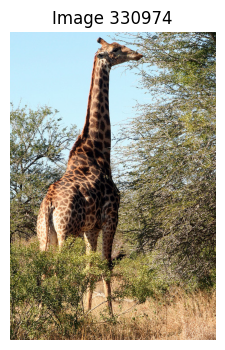

Image 330974:
  Actual:    A b=very large robust giraffe eating leaves from trees
  Predicted: a giraffe standing in a tall tree branch .



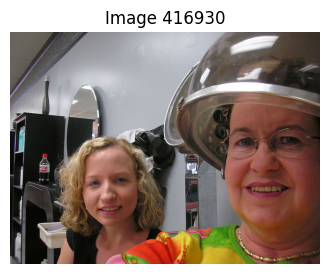

Image 416930:
  Actual:    The women are getting their hair done in the salon. 
  Predicted: a woman in a red shirt holding a cell phone



In [1]:
from clearml import Dataset, Task
import json
import os
from pathlib import Path
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision as tv
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import nltk
import random
from collections import Counter

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

print("\n" + "=" * 60)
print("ОБУЧЕНИЕ МОДЕЛИ IMAGE CAPTIONING В CLEARML (STAGE 2)")
print("=" * 60)

IMAGE_DATASET_NAME = "ImageDesc_dataset_v1"
IMAGE_DATASET_VERSION = "1.0.0"
CAPTIONS_DATASET_NAME = "captions_vall"
CAPTIONS_DATASET_VERSION = "1.0.0"
PROJECT_NAME = "Image description generation"

print("Получение датасетов из ClearML...")
try:
    image_dataset = Dataset.get(
        dataset_name=IMAGE_DATASET_NAME,
        dataset_project=PROJECT_NAME,
        dataset_version=IMAGE_DATASET_VERSION
    )
    print(f"Датасет изображений найден: {image_dataset.id}")
except ValueError as e:
    print(f"Датасет изображений не найден: {e}")
    raise

try:
    captions_dataset = Dataset.get(
        dataset_name=CAPTIONS_DATASET_NAME,
        dataset_project=PROJECT_NAME,
        dataset_version=CAPTIONS_DATASET_VERSION
    )
    print(f"Датасет аннотаций найден: {captions_dataset.id}")
except ValueError as e:
    print(f"Датасет аннотаций не найден: {e}")
    raise

image_local_path = image_dataset.get_local_copy()
captions_local_path = captions_dataset.get_local_copy()
captions_file = Path(captions_local_path) / "captions_val2014.json"

print(f"Изображения: {image_local_path}")
print(f"Аннотации: {captions_file}")

if not os.path.exists(image_local_path):
    raise FileNotFoundError(f"Папка изображений не найдена: {image_local_path}")
if not captions_file.exists():
    raise FileNotFoundError(f"Файл аннотаций не найден: {captions_file}")

with open(captions_file, "r", encoding="utf-8") as f:
    captions_list = json.load(f)["annotations"]

captions_data = {}
for ann in captions_list:
    img_id = ann["image_id"]
    if img_id not in captions_data:
        captions_data[img_id] = {"captions": []}
    captions_data[img_id]["captions"].append(ann["caption"])

print(f"Аннотации загружены: {len(captions_data)} изображений")

MAX_IMAGES = 40000
all_image_ids = list(captions_data.keys())[:MAX_IMAGES]
random.shuffle(all_image_ids)

val_ratio = 0.1
val_size = int(len(all_image_ids) * val_ratio)

val_image_ids = all_image_ids[:val_size]
train_image_ids = all_image_ids[val_size:]

print(f"Всего изображений: {len(all_image_ids)}")
print(f"Train: {len(train_image_ids)}")
print(f"Validation: {len(val_image_ids)}")

task = Task.init(
    project_name=PROJECT_NAME,
    task_name="Image_Captioning_Training_Stage2",
    output_uri=None
)
print(f"ClearML Task создана: {task.id}")

MAX_CAPTION_WORDS = 10
MAX_SEQ_LEN = MAX_CAPTION_WORDS + 2

task.connect({
    "image_dataset": IMAGE_DATASET_NAME,
    "captions_dataset": CAPTIONS_DATASET_NAME,
    "image_path": image_local_path,
    "captions_path": str(captions_file),
    "max_images": MAX_IMAGES,
    "val_ratio": val_ratio,
    "max_caption_words": MAX_CAPTION_WORDS,
})

def build_vocab(captions_data, threshold=5):
    counter = Counter()
    for img_data in captions_data.values():
        for caption in img_data["captions"]:
            tokens = nltk.word_tokenize(caption.lower())
            counter.update(tokens)

    words = [word for word, cnt in counter.items() if cnt >= threshold]
    vocab = {word: idx for idx, word in enumerate(words, start=4)}
    vocab["<pad>"] = 0
    vocab["<start>"] = 1
    vocab["<end>"] = 2
    vocab["<unk>"] = 3
    return vocab

vocab = build_vocab(captions_data)
vocab_size = len(vocab)
print(f"Словарь создан: {vocab_size} слов")

def tokenize_caption(caption, vocab, max_len=MAX_SEQ_LEN):
    tokens = nltk.word_tokenize(caption.lower())
    tokens = [vocab["<start>"]] + [vocab.get(token, vocab["<unk>"]) for token in tokens] + [vocab["<end>"]]

    if len(tokens) > max_len:
        tokens = tokens[:max_len]
        tokens[-1] = vocab["<end>"]
    else:
        tokens += [vocab["<pad>"]] * (max_len - len(tokens))

    return torch.tensor(tokens, dtype=torch.long)

class CaptionDataset(torch.utils.data.Dataset):
    def __init__(self, image_path, captions_data, vocab, transform, image_ids=None):
        self.image_path = Path(image_path)
        self.captions_data = captions_data
        self.vocab = vocab
        self.transform = transform
        self.image_ids = image_ids if image_ids is not None else list(captions_data.keys())

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = self.image_path / f"COCO_val2014_{img_id:012d}.jpg"
        image = tv.io.read_image(str(img_path)).float() / 255.0

        if image.size(0) == 1:
            image = image.repeat(3, 1, 1)

        if self.transform:
            image = self.transform(image)

        caption = random.choice(self.captions_data[img_id]["captions"])
        caption_tensor = tokenize_caption(caption, self.vocab)

        return image, caption_tensor

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = CaptionDataset(
    image_local_path, captions_data, vocab, transform, image_ids=train_image_ids
)
val_dataset = CaptionDataset(
    image_local_path, captions_data, vocab, transform, image_ids=val_image_ids
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = device.type == "cuda"

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory
)

class EncoderCNN(nn.Module):
    def __init__(self, embed_size, hidden_size):
        super().__init__()
        weights = tv.models.ResNet50_Weights.DEFAULT
        resnet = tv.models.resnet50(weights=weights)

        for param in resnet.parameters():
            param.requires_grad_(False)

        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)
        self.embed = nn.Linear(resnet.fc.in_features, hidden_size)

    def forward(self, images):
        features = self.resnet(images)
        features = features.view(features.size(0), -1)
        features = self.embed(features)
        return features

class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions):
        embeddings = self.embed(captions[:, :-1])
        h0 = features.unsqueeze(0).repeat(self.lstm.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        outputs, _ = self.lstm(embeddings, (h0, c0))
        outputs = self.linear(outputs)
        return outputs

class CaptionModel(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super().__init__()
        self.encoder = EncoderCNN(embed_size, hidden_size)
        self.decoder = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs

embed_size = 256
hidden_size = 512
num_layers = 1

model = CaptionModel(embed_size, hidden_size, vocab_size, num_layers).to(device)
print(f"\nОбучение будет выполняться на: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=vocab["<pad>"])

def evaluate(model, dataloader, criterion, device, vocab_size):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for images, captions in dataloader:
            images = images.to(device, non_blocking=True)
            captions = captions.to(device, non_blocking=True)

            outputs = model(images, captions)
            loss = criterion(
                outputs.reshape(-1, vocab_size),
                captions[:, 1:].contiguous().reshape(-1)
            )
            total_loss += loss.item()

    return total_loss / len(dataloader)

num_epochs = 50
print("Начинаем обучение...")
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for i, (images, captions) in enumerate(train_loader):
        images = images.to(device, non_blocking=True)
        captions = captions.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images, captions)

        loss = criterion(
            outputs.reshape(-1, vocab_size),
            captions[:, 1:].contiguous().reshape(-1)
        )

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        task.get_logger().report_scalar(
            "Batch Loss",
            "Train",
            loss.item(),
            iteration=epoch * len(train_loader) + i
        )

    avg_train_loss = epoch_loss / len(train_loader)
    avg_val_loss = evaluate(model, val_loader, criterion, device, vocab_size)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"Train Loss: {avg_train_loss:.4f}, "
        f"Val Loss: {avg_val_loss:.4f}"
    )

    task.get_logger().report_scalar("Epoch Loss", "Train", avg_train_loss, iteration=epoch)
    task.get_logger().report_scalar("Epoch Loss", "Validation", avg_val_loss, iteration=epoch)

plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o", label="Train Loss")
plt.plot(range(1, num_epochs + 1), val_losses, marker="s", label="Val Loss")
plt.title("Train / Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("train_val_loss_stage2.png")
plt.show()

task.upload_artifact("train_val_loss_plot", "train_val_loss_stage2.png")

checkpoint = {
    "model_state_dict": model.state_dict(),
    "vocab": vocab,
    "embed_size": embed_size,
    "hidden_size": hidden_size,
    "num_layers": num_layers,
    "max_caption_words": MAX_CAPTION_WORDS,
}

torch.save(checkpoint, "caption_model_stage2_checkpoint.pth")
task.upload_artifact("model_checkpoint", "caption_model_stage2_checkpoint.pth")

print("Обучение завершено! Модель и графики сохранены и залогированы в ClearML.")

inv_vocab = {idx: word for word, idx in vocab.items()}

def generate_caption(model, image, vocab, inv_vocab, device, max_len=MAX_CAPTION_WORDS):
    model.eval()
    with torch.no_grad():
        image = image.unsqueeze(0).to(device)
        features = model.encoder(image)

        hidden = features.unsqueeze(0).repeat(model.decoder.lstm.num_layers, 1, 1)
        cell = torch.zeros_like(hidden)
        states = (hidden, cell)

        inputs = torch.tensor([[vocab["<start>"]]], dtype=torch.long, device=device)
        caption = []

        for _ in range(max_len):
            embeddings = model.decoder.embed(inputs)
            outputs, states = model.decoder.lstm(embeddings, states)
            outputs = model.decoder.linear(outputs.squeeze(1))
            predicted = outputs.argmax(dim=1)
            predicted_idx = predicted.item()

            if predicted_idx == vocab["<end>"]:
                break
            if predicted_idx not in {vocab["<start>"], vocab["<pad>"]}:
                caption.append(inv_vocab.get(predicted_idx, "<unk>"))

            inputs = predicted.unsqueeze(0)

        return " ".join(caption)

def show_intermediate_results(model, dataset, captions_data, vocab, inv_vocab, device, transform, task, n=3):
    model.eval()
    debug_dir = Path("debug_samples")
    debug_dir.mkdir(exist_ok=True)

    print("\nПромежуточные примеры:")
    sample_ids = random.sample(dataset.image_ids, min(n, len(dataset.image_ids)))

    for img_id in sample_ids:
        img_path = dataset.image_path / f"COCO_val2014_{img_id:012d}.jpg"
        raw_image = tv.io.read_image(str(img_path)).float() / 255.0

        if raw_image.size(0) == 1:
            raw_image = raw_image.repeat(3, 1, 1)

        display_image = raw_image.permute(1, 2, 0).cpu().numpy()
        plt.figure(figsize=(4, 4))
        plt.imshow(display_image)
        plt.axis("off")
        plt.title(f"Image {img_id}")
        plt.show()

        sample_file = debug_dir / f"sample_{img_id}.png"
        plt.imsave(sample_file, display_image)
        task.upload_artifact(f"debug_samples/images/image_{img_id}", str(sample_file))

        image = transform(raw_image)
        predicted = generate_caption(model, image, vocab, inv_vocab, device)
        actual = random.choice(captions_data[img_id]["captions"])

        print(f"Image {img_id}:")
        print(f"  Actual:    {actual}")
        print(f"  Predicted: {predicted}\n")

        info_file = debug_dir / f"sample_{img_id}.txt"
        info_text = (
            f"Image {img_id}\n"
            f"Image path: {img_path}\n"
            f"Actual: {actual}\n"
            f"Predicted: {predicted}\n"
        )
        info_file.write_text(info_text, encoding="utf-8")
        task.upload_artifact(f"debug_samples/labels/info_{img_id}", str(info_file))

show_intermediate_results(
    model,
    val_dataset,
    captions_data,
    vocab,
    inv_vocab,
    device,
    transform,
    task,
    n=10
)

task.close()
